# EDA — IBM HR Analytics (Synthetic Employee Dataset)

This notebook performs an exploratory analysis of the IBM HR Analytics dataset, focusing on organizational structure and compensation patterns.


In [7]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub



## 1) Data loading


In [8]:
# Download and load the CSV from Kaggle (IBM HR Analytics)
path = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')
print('Path to dataset files:', path)

csv_name = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
full_csv_path = os.path.join(path, csv_name)

if os.path.exists(full_csv_path):
    df = pd.read_csv(full_csv_path)
    print(f'Successfully loaded {csv_name}.')
    display(df.head())
else:
    raise FileNotFoundError(f"{csv_name} not found. Files available: {os.listdir(path)}")


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset
Successfully loaded WA_Fn-UseC_-HR-Employee-Attrition.csv.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2) Quick dataset values checks


In [9]:
# Inspect column names
df.columns


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [10]:
# Dataset dimensions (rows, columns)
df.shape


(1470, 35)

In [11]:
#Check for missing, null or dup values
print("Total employees:", len(df))
print("Number of features:", df.shape[1])
print(f"Number of duplicated values:  {df.duplicated().sum()}")
print(f"Number of null values: {df.isnull().sum().sum()}")
print(f"Number of missing values: {df.isna().sum().sum()}")

Total employees: 1470
Number of features: 35
Number of duplicated values:  0
Number of null values: 0
Number of missing values: 0


In [12]:
df.dtypes.value_counts()

,count
int64,26
object,9


In [13]:
numerical_columns = df.select_dtypes(include= 'int').columns
print(numerical_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [14]:
categorical_columns = df.select_dtypes(include= 'object').columns
print(categorical_columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [15]:
# Encode Attrition as binary (Yes=1, No=0)
df['Attrition'] = df['Attrition'].map({'Yes': 1,
                                       'No' : 0})

In [16]:
print("Attrition rate (%):", df['Attrition'].mean()*100)

Attrition rate (%): 16.122448979591837


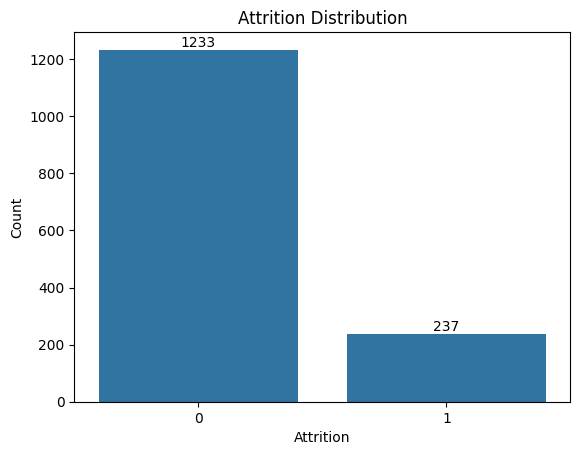

In [17]:
# Attrition distribution
ax = sns.countplot(data=df, x='Attrition')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.title('Attrition Distribution')
plt.ylabel('Count')
plt.show()


## 3) Feature relationships (correlation heatmap)


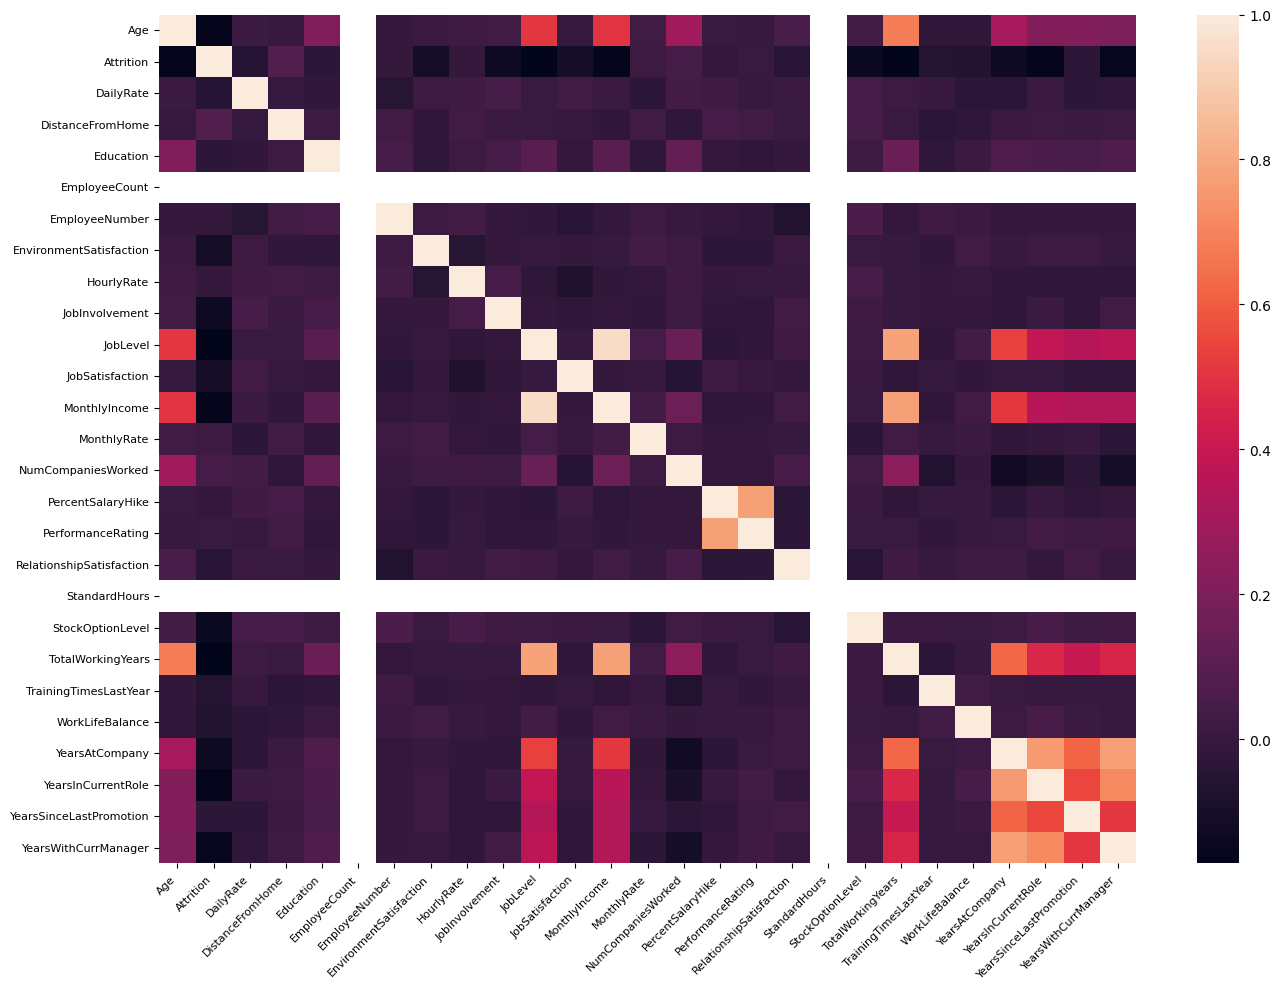

In [18]:
# Correlation heatmap (numerical features)
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='rocket')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


## 4) Organizational structure (Departments & Education)
Here we try to figure it out what type of company we are working with


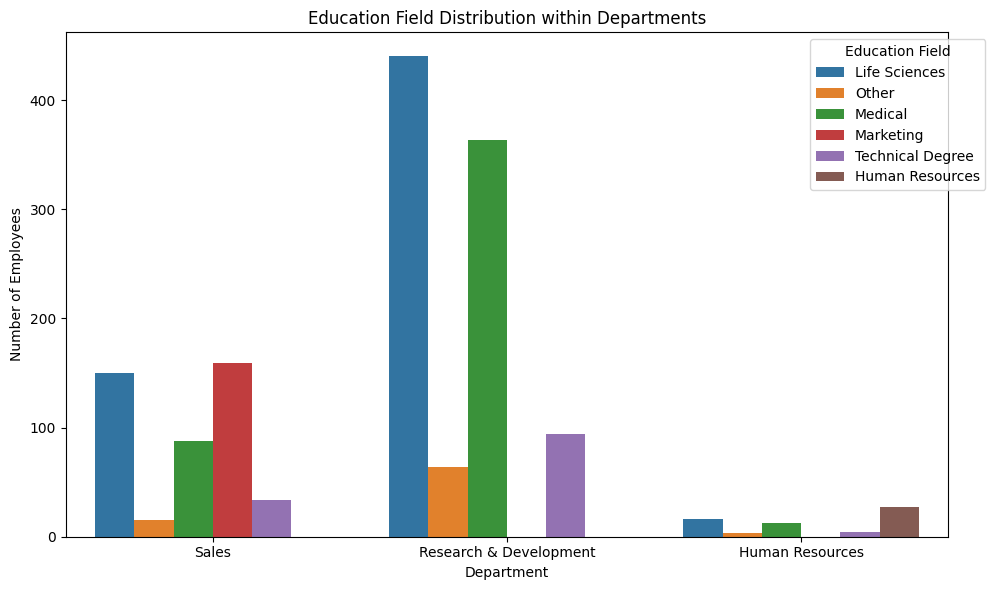

In [19]:
#Company Structure
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Department',
    hue='EducationField'
)

plt.title('Education Field Distribution within Departments')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Education Field', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [20]:
# Employees per department
df['Department'].value_counts()


,count
Department,
Research & Development,961
Sales,446
Human Resources,63


Probably we are working with a product oriented company

Lets see what types of studies this people did:

In [21]:
# Employees per education field
df['EducationField'].value_counts()


,count
EducationField,
Life Sciences,606
Medical,464
Marketing,159
Technical Degree,132
Other,82
Human Resources,27


In [22]:
# Education field distribution within each department
df.groupby('Department')['EducationField'].value_counts()

Department              EducationField  
Human Resources         Human Resources      27
                        Life Sciences        16
                        Medical              13
                        Technical Degree      4
                        Other                 3
Research & Development  Life Sciences       440
                        Medical             363
                        Technical Degree     94
                        Other                64
Sales                   Marketing           159
                        Life Sciences       150
                        Medical              88
                        Technical Degree     34
                        Other                15
Name: count, dtype: int64

If we had to guess, we would say that we are working with a Pharmaceutical/ BioTech Company

In [23]:
#Looking for the "size" of the company
total_spending_month = df.groupby('Department')['MonthlyIncome'].sum().sum()
print(df.groupby('Department')['MonthlyIncome'].sum())
print(f"Total Spending: {total_spending_month}$")

Department
Human Resources            419234
Research & Development    6036284
Sales                     3103791
Name: MonthlyIncome, dtype: int64
Total Spending: 9559309$


9.5M $/month, HUGE COMPANY!

Lets explore the Gender BIAS

## 5) Workforce demographics (Gender)


In [24]:
# Gender counts
counts = df['Gender'].value_counts()
counts


,count
Gender,
Male,882
Female,588


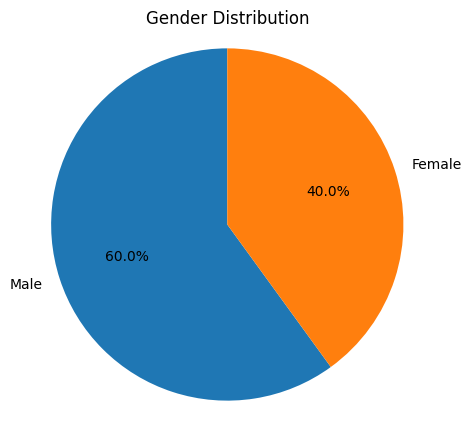

In [25]:
#Pie plot for better visualization
gender_counts = df['Gender'].value_counts()


plt.figure(figsize=(5,5))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

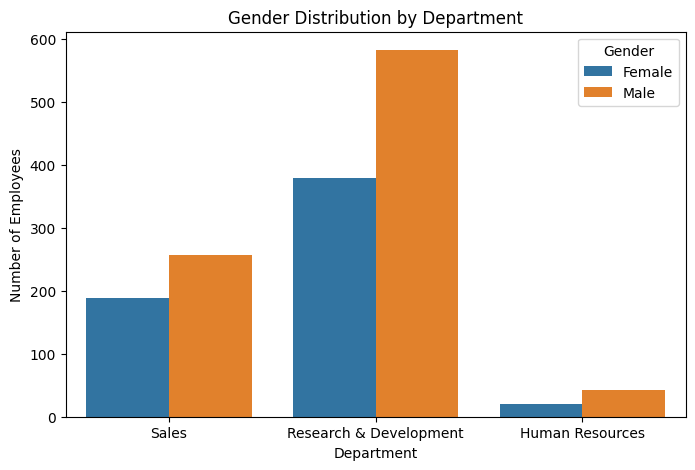

In [26]:
#Barplot to see the gender distribution between departments
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Department',
    hue='Gender'
)

plt.title('Gender Distribution by Department')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.show()

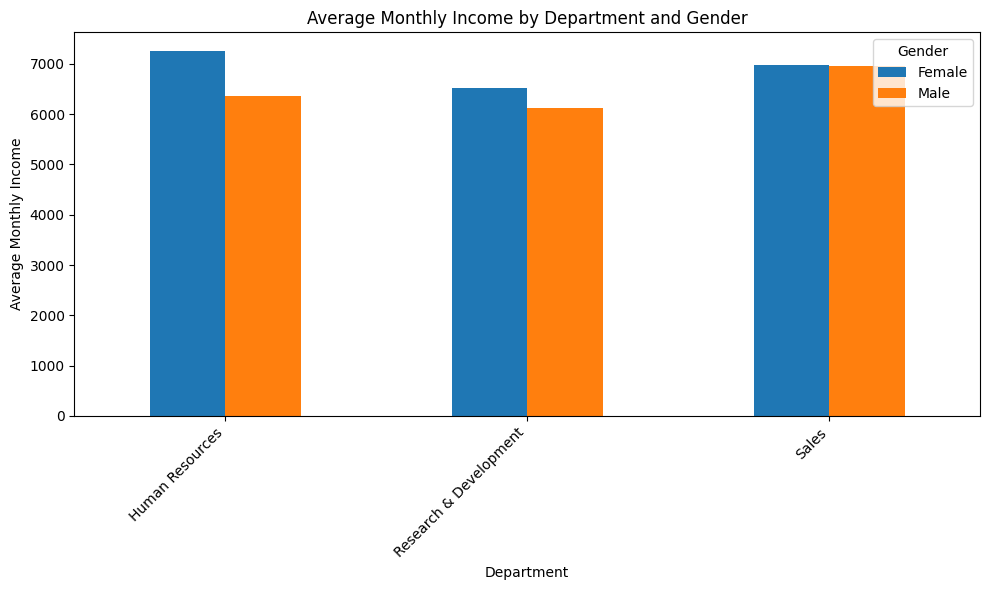

In [27]:
#Average Monthly Income by Department and Gender
pivot = df.groupby(['Department', 'Gender'])['MonthlyIncome'].mean().unstack()

pivot.plot(kind='bar', figsize=(10,6))

plt.title('Average Monthly Income by Department and Gender')
plt.ylabel('Average Monthly Income')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [28]:
#Overral wich gender receives more?
mean_by_gender = df.groupby('Gender')['MonthlyIncome'].mean()
print(f"Mean payment of each {mean_by_gender}")

Mean payment of each Gender
Female    6686.566327
Male      6380.507937
Name: MonthlyIncome, dtype: float64


Females receive, in average, 306$ more!

##Our next goal is to find the cause for this gap

In [29]:
#Now lets see if exist payment difference in the same jobRole
df.groupby(['JobRole', 'Gender'])['MonthlyIncome'].mean().unstack()

Gender,Female,Male
JobRole,,
Healthcare Representative,7433.803922,7589.300000
Human Resources,4540.687500,4100.222222
Laboratory Technician,3246.905882,3232.413793
Manager,16915.276596,17409.327273
Manufacturing Director,7409.166667,7182.671233
Research Director,15144.484848,16657.787234
Research Scientist,3344.473684,3173.044944
Sales Executive,6764.310606,7033.123711
Sales Representative,2671.947368,2587.200000


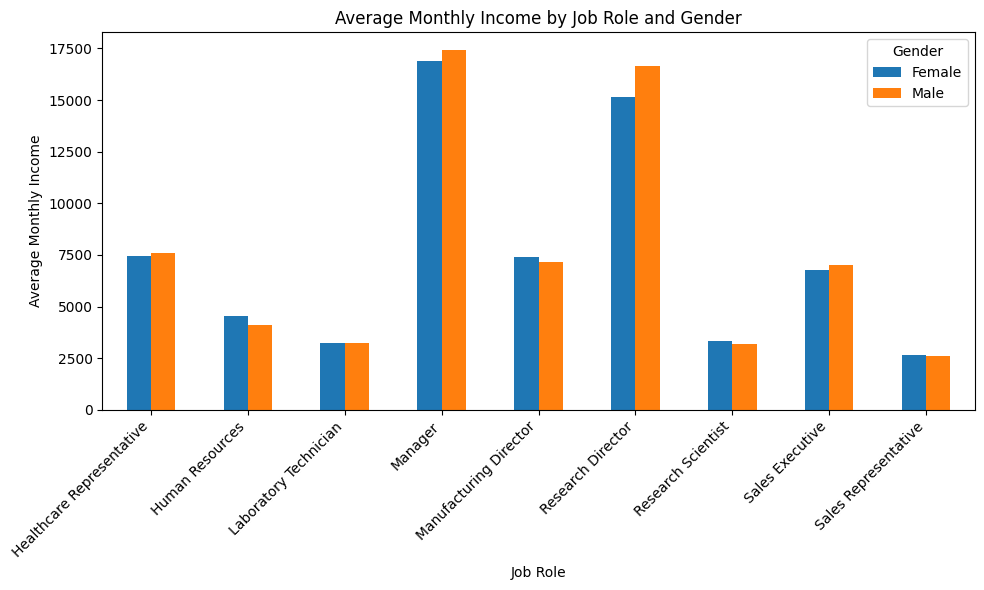

In [30]:
#Lets plot it
pivot = df.groupby(['JobRole', 'Gender'])['MonthlyIncome'].mean().unstack()

pivot.plot(kind='bar', figsize=(10,6))

plt.title('Average Monthly Income by Job Role and Gender')
plt.ylabel('Average Monthly Income')
plt.xlabel('Job Role')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

Overall

In [31]:
# HR table: average salary by role, level and gender
hr_salary = (
    df[df['Department'] == 'Human Resources']
    .groupby(['JobRole','JobLevel','Gender'])['MonthlyIncome']
    .mean()
    .unstack()
)

hr_salary

Gender                          Female          Male
JobRole         JobLevel                            
Human Resources 1          2653.000000   2768.086957
                2          5859.333333   5474.700000
                3          9514.333333   9731.666667
Manager         4         17063.500000  15231.500000
                5         19251.000000  19176.600000

In [32]:
# R&D table: salary summary by job level and gender
rd_summary = (
    df[df['Department'] == 'Research & Development']
    .groupby(['JobLevel','Gender'])
    .agg(
        Count=('MonthlyIncome','size'),
        AvgSalary=('MonthlyIncome','mean')
    )
    .reset_index()
)

rd_summary

,JobLevel,Gender,Count,AvgSalary
0,1,Female,154,2848.701299
1,1,Male,280,2835.314286
2,2,Female,116,5251.474138
3,2,Male,165,5319.193939
4,3,Female,62,10271.290323
5,3,Male,67,10077.208955
6,4,Female,31,15398.225806
7,4,Male,37,15832.783784
8,5,Female,16,19165.812500
9,5,Male,33,19244.060606


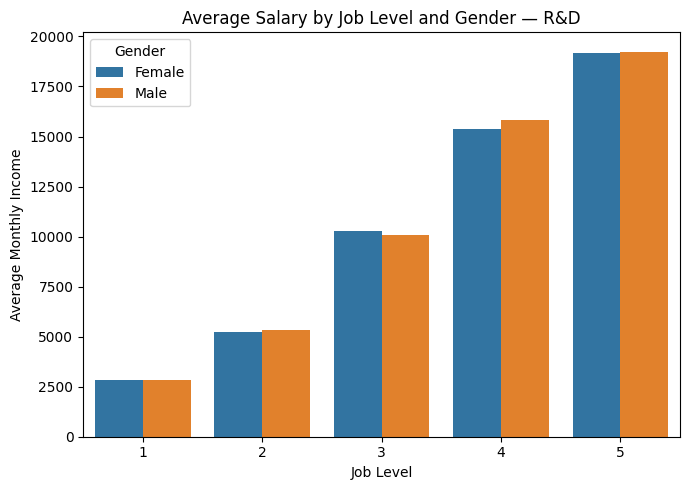

In [33]:
# R&D: average salary by job level and gender
plt.figure(figsize=(7,5))
sns.barplot(data=rd_summary, x='JobLevel', y='AvgSalary', hue='Gender', errorbar=None)
plt.title('Average Salary by Job Level and Gender — R&D')
plt.xlabel('Job Level')
plt.ylabel('Average Monthly Income')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


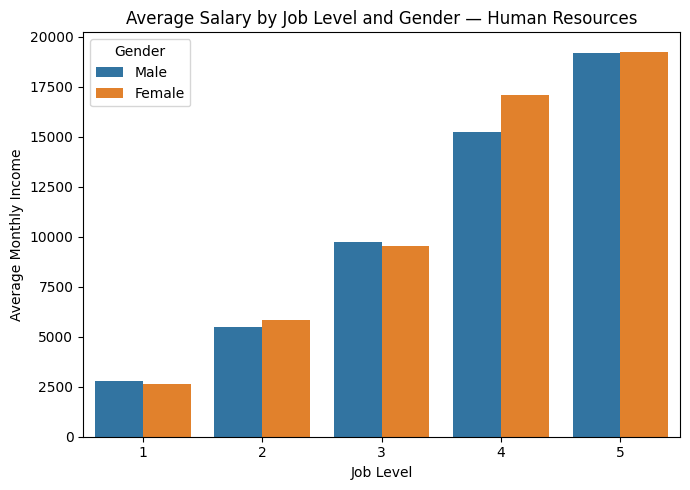

In [34]:
# HR: average salary by job level and gender
hr = df[df['Department'] == 'Human Resources']

plt.figure(figsize=(7,5))
sns.barplot(data=hr, x='JobLevel', y='MonthlyIncome', hue='Gender', estimator='mean', errorbar=None)
plt.title('Average Salary by Job Level and Gender — Human Resources')
plt.xlabel('Job Level')
plt.ylabel('Average Monthly Income')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


## 6) Extra Analysis


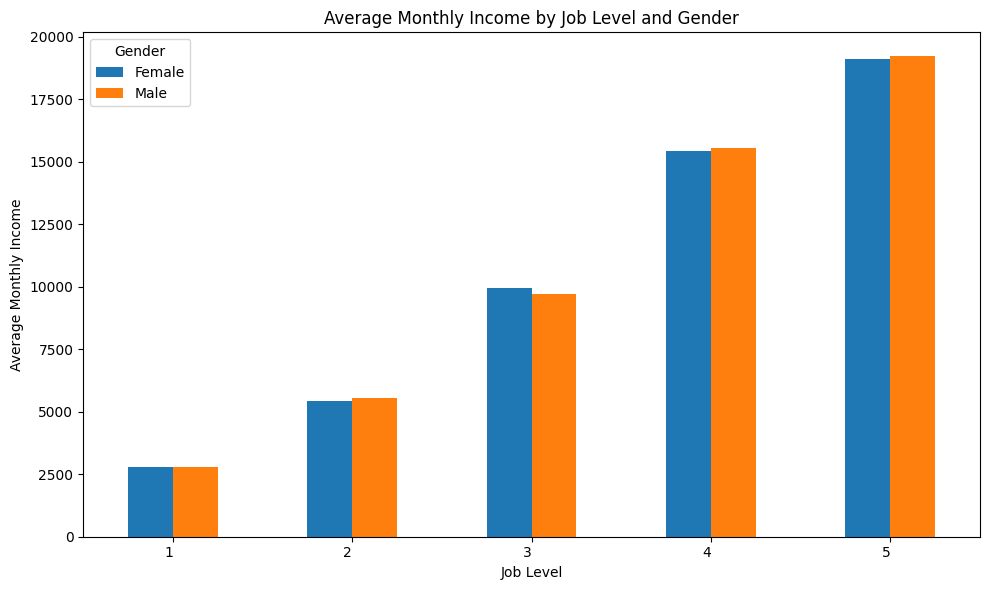

In [36]:
pivot = df.groupby(['JobLevel', 'Gender'])['MonthlyIncome'].mean().unstack()

pivot.plot(kind='bar', figsize=(10,6))

plt.title('Average Monthly Income by Job Level and Gender')
plt.ylabel('Average Monthly Income')
plt.xlabel('Job Level')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

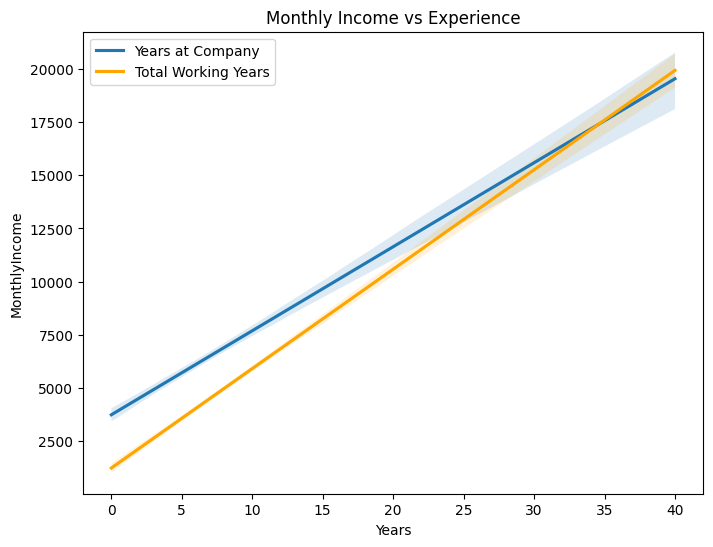

In [35]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='YearsAtCompany',
    y='MonthlyIncome',
    scatter=False,
    label='Years at Company'
)
sns.regplot(
    data=df,
    x='TotalWorkingYears',
    y='MonthlyIncome',
    scatter=False,
    label='Total Working Years',
    color='orange'
)

plt.legend()
plt.xlabel('Years')
plt.title('Monthly Income vs Experience')
plt.show()

In [37]:
df.groupby(
    ['JobLevel', 'Gender']
).agg(
    avg_salary=('MonthlyIncome', 'mean'),
    avg_experience=('TotalWorkingYears', 'mean')
)

avg_salary  avg_experience
JobLevel Gender                              
1        Female   2780.487437        6.030151
         Male     2790.633721        5.811047
2        Female   5435.327273       10.486364
         Male     5549.184713       10.378981
3        Female   9962.702128       15.872340
         Male     9706.991935       14.548387
4        Female  15431.372549       25.098039
         Male    15570.927273       25.818182
5        Female  19129.916667       25.666667
         Male    19224.844444       26.755556